## Carregamento e Visualização


ANALISE DESCRITIVA DOS DATASETS

=== PROD_AGRICOLA ===
                Ano                  Variável         Valor
count     69.000000                        69  6.900000e+01
unique          NaN                         3           NaN
top             NaN  Área plantada (Hectares)           NaN
freq            NaN                        23           NaN
mean    2013.000000                       NaN  1.309437e+08
std        6.681845                       NaN  1.503467e+08
min     2002.000000                       NaN  4.699400e+07
25%     2007.000000                       NaN  5.905960e+07
50%     2013.000000                       NaN  7.327434e+07
75%     2019.000000                       NaN  9.165108e+07
max     2024.000000                       NaN  7.163265e+08

=== PIB ===
               Ano  Região  PIB-Milhões de Reais
count     23.00000      23          2.300000e+01
unique         NaN       1                   NaN
top            NaN  Brasil                   NaN
freq           

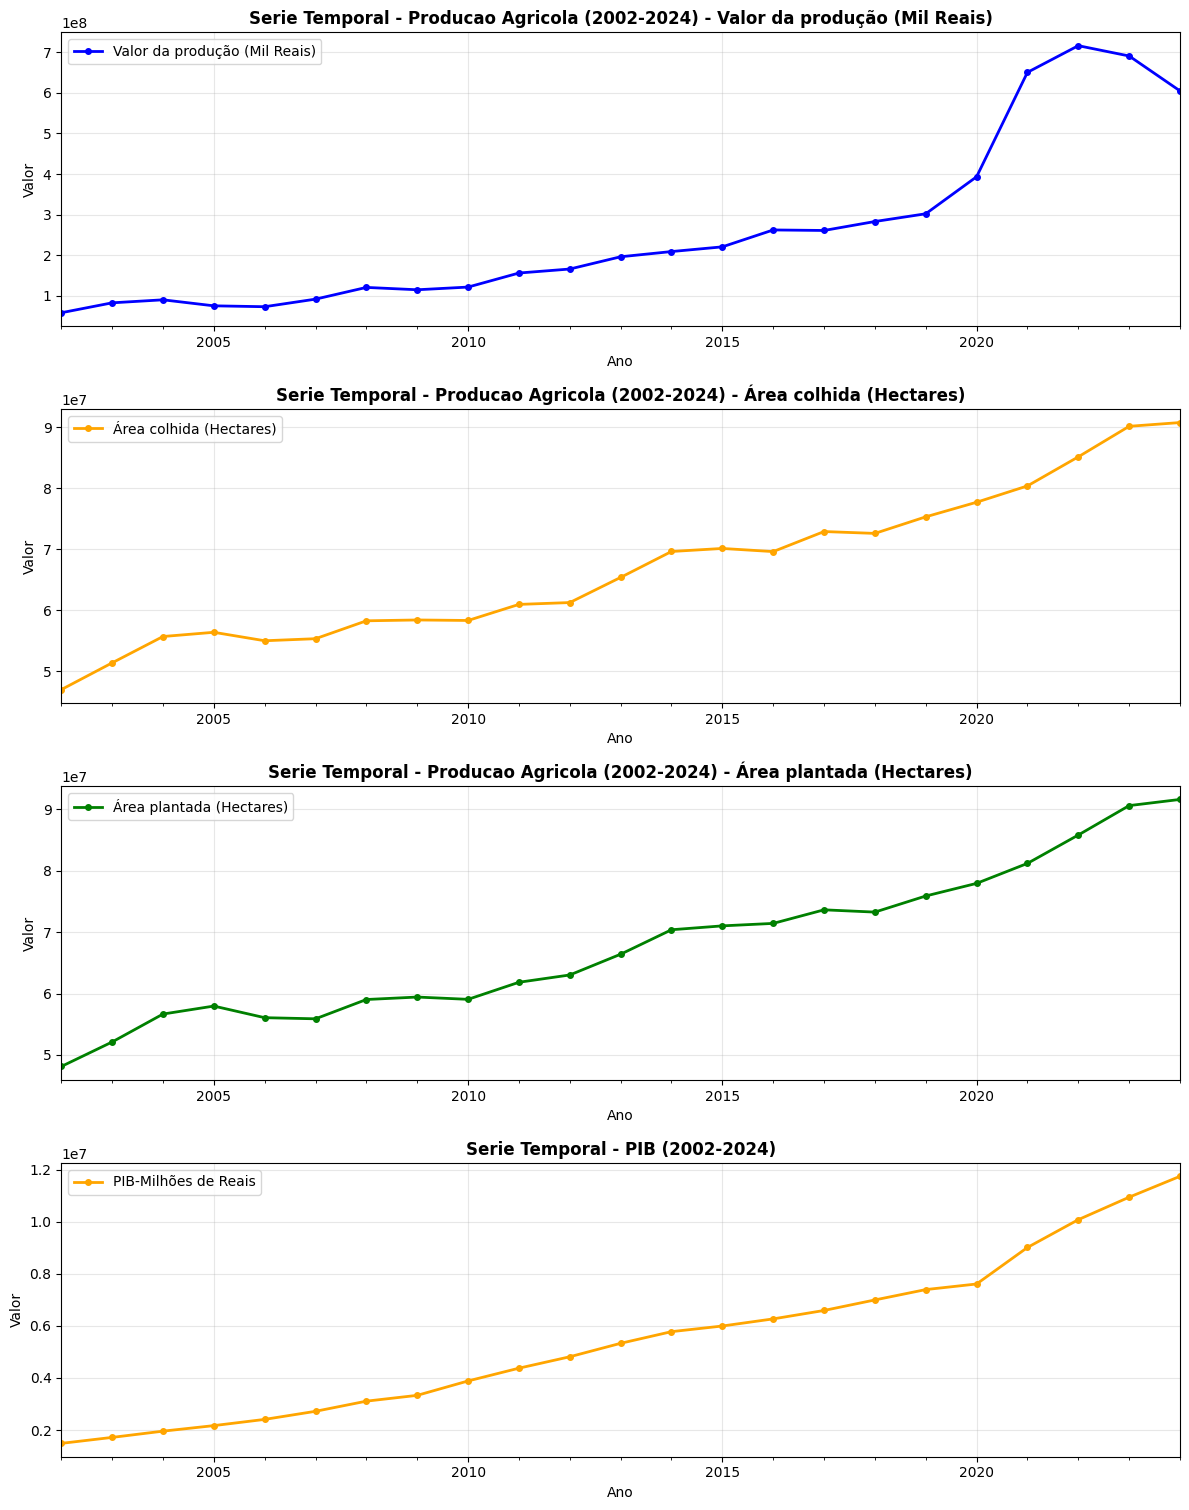


PLOTANDO HISTOGRAMAS


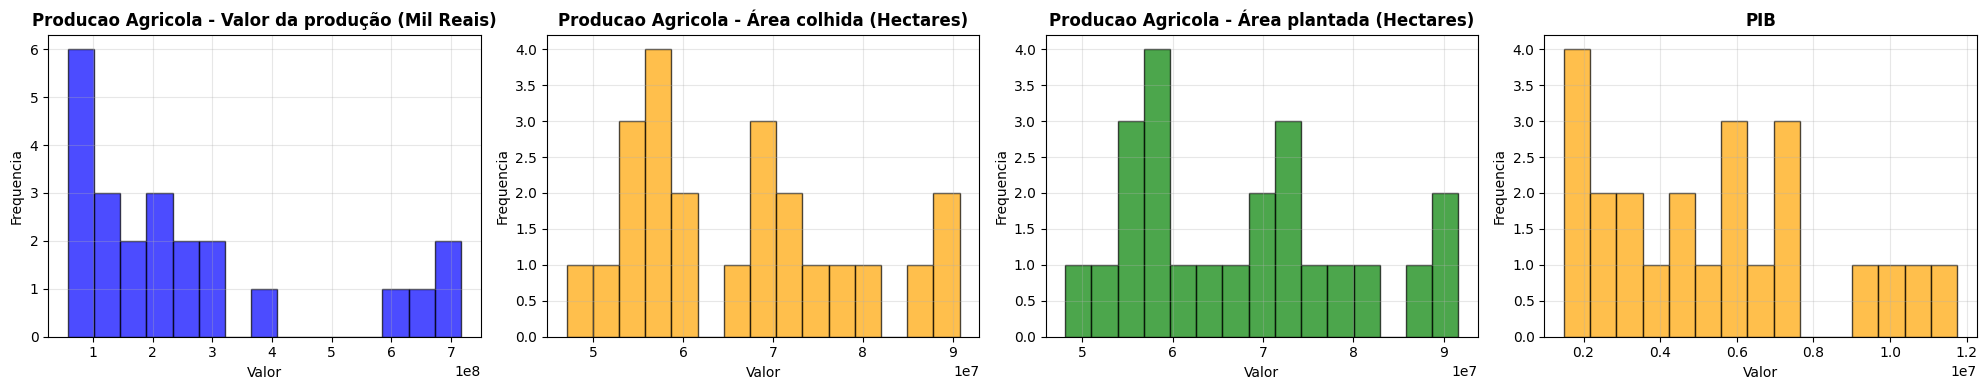

In [ ]:
from typing import Dict, Optional, List
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FUNCOES DE CARREGAMENTO E PRE-PROCESSAMENTO
# ============================================================

def load_data(file_paths: Dict[str, str]) -> Dict[str, pd.DataFrame]:
    """Carrega multiplos arquivos CSV"""
    datasets: Dict[str, pd.DataFrame] = {}
    for name, path in file_paths.items():
        datasets[name] = pd.read_csv(path, header="infer", sep=",")
    return datasets


def convert_last_n_columns_to_numeric(df: pd.DataFrame, n: int = 1, errors: str = 'coerce') -> pd.DataFrame:
    """Converte as ultimas n colunas para tipo numerico"""
    df_copy = df.copy()
    for col in df_copy.columns[-n:]:
        df_copy[col] = pd.to_numeric(df_copy[col], errors=errors)
    return df_copy


def clean_data_with_dropna(df: pd.DataFrame, name: str = "Dataset") -> pd.DataFrame:
    """Remove linhas com NaN e valores invalidos, mostra a porcentagem removida"""
    if "Região" in df.columns:
        df = df.drop(columns=["Região"])

    rows_before: int = len(df)
    df_clean = df.dropna(how="any")
    rows_after: int = len(df_clean)

    if rows_before > 0:
        removed: int = rows_before - rows_after
        percentage: float = (removed / rows_before) * 100
        print(f"\n{name}:")
        print(f"  Linhas antes: {rows_before}")
        print(f"  Linhas apos limpeza: {rows_after}")
        print(f"  Linhas removidas: {removed}")
        print(f"  Percentual removido: {percentage:.2f}%")

    assert not df_clean.isna().any().any(), f"{name}: ainda existem valores NaN apos dropna."
    return df_clean


def prepare_prod_agricola_multilevel(df: pd.DataFrame, name: str = "PROD_AGRICOLA") -> pd.DataFrame:
    """
    Padroniza prod_agricola para MultiIndex anual:
    - nivel 0: Ano
    - nivel 1: Variavel
    - coluna de valor: valor
    """
    df_prep: pd.DataFrame = df.copy()
    print(f"\n{name}:")

    required_cols = {"Ano", "Variável", "Valor"}
    missing_cols = required_cols - set(df_prep.columns)
    if missing_cols:
        raise ValueError(f"{name}: colunas obrigatorias ausentes: {sorted(missing_cols)}")

    df_prep["Ano"] = pd.to_numeric(df_prep["Ano"], errors="coerce")
    df_prep = df_prep.dropna(subset=["Ano"])
    df_prep["Ano"] = df_prep["Ano"].astype(int).astype(str).apply(lambda x: pd.Period(x.strip(), freq='Y'))

    df_prep["Valor"] = pd.to_numeric(df_prep["Valor"], errors="coerce")
    df_prep = df_prep.dropna(subset=["Variável", "Valor"])
    df_prep = df_prep.rename(columns={"Valor": "valor"})
    df_prep = df_prep.set_index(["Ano", "Variável"]).sort_index()

    print("  - MultiIndex criado: (Ano, Variável)")
    print("  - Coluna de valores: valor")
    return df_prep


def prepare_data_for_analysis(df: pd.DataFrame, name: str = "Dataset") -> pd.DataFrame:
    """
    Prepara dados anuais para analise generica:
    1. Converte a coluna Ano para PeriodIndex anual
    2. Cria indice temporal (e MultiIndex quando existir coluna categorica adicional)
    """
    df_prep: pd.DataFrame = df.copy()
    print(f"\n{name}:")

    if "Ano" not in df_prep.columns:
        raise ValueError(f"{name}: coluna 'Ano' obrigatoria para serie anual.")

    df_prep["Ano"] = pd.to_numeric(df_prep["Ano"], errors="coerce")
    df_prep = df_prep.dropna(subset=["Ano"])
    df_prep["Ano"] = df_prep["Ano"].astype(int).astype(str).apply(lambda x: pd.Period(x.strip(), freq='Y'))
    print("  - 'Ano' convertido para timestamp anual")

    secondary_levels: List[str] = [
        col for col in df_prep.columns
        if col != "Ano" and not pd.api.types.is_numeric_dtype(df_prep[col])
    ]

    if secondary_levels:
        index_cols: List[str] = ["Ano"] + secondary_levels
        df_prep = df_prep.set_index(index_cols)
        print(f"  - Convertido para MultiIndex ({', '.join(index_cols)})")
    else:
        df_prep = df_prep.set_index("Ano")
        print("  - Convertido para indice temporal (Ano)")

    return df_prep


def show_descriptive_stats(datasets: Dict[str, pd.DataFrame]) -> None:
    """Mostra estatisticas descritivas de multiplos datasets"""
    print("\n" + "=" * 60)
    print("ANALISE DESCRITIVA DOS DATASETS")
    print("=" * 60)
    for name, df in datasets.items():
        print(f"\n=== {name.upper()} ===")
        print(df.describe(include='all'))


# ============================================================
# FUNCOES DE VISUALIZACAO
# ============================================================

def _prepare_for_time_plot(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza DataFrame para plot temporal, inclusive quando houver MultiIndex."""
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    if numeric_df.empty:
        return pd.DataFrame(index=df.index)

    if isinstance(numeric_df.index, pd.MultiIndex) and numeric_df.index.nlevels > 1:
        # Para dados anuais com categoria (ex.: Variavel), separa cada categoria em uma serie.
        first_numeric_col = numeric_df.columns[0]
        return numeric_df[first_numeric_col].unstack(level=1)

    return numeric_df


def plot_time_series(
    datasets: Dict[str, pd.DataFrame],
    titles: Optional[List[str]] = None,
    colors: Optional[List[str]] = None
) -> None:
    """Plota series temporais de multiplos datasets"""
    default_colors: List[str] = ['tab:blue', 'tab:orange', 'tab:green']
    plot_items: List[tuple] = []

    for idx, (name, df) in enumerate(datasets.items()):
        base_title = titles[idx] if titles else f'Serie Temporal - {name}'
        plot_df = _prepare_for_time_plot(df)
        color = colors[idx] if colors and idx < len(colors) else default_colors[idx % len(default_colors)]

        if plot_df.empty:
            plot_items.append((f"{base_title} (sem colunas numericas)", plot_df, color))
            continue

        if name == "prod_agricola" and plot_df.shape[1] > 1:
            for j, col in enumerate(plot_df.columns):
                split_color = colors[j] if colors and j < len(colors) else default_colors[j % len(default_colors)]
                plot_items.append((f"{base_title} - {col}", plot_df[[col]], split_color))
        else:
            plot_items.append((base_title, plot_df, color))

    n_plots = len(plot_items)
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3.8 * n_plots))

    if n_plots == 1:
        axes = [axes]

    for ax, (title, plot_df, color) in zip(axes, plot_items):
        if plot_df.empty:
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            continue

        if plot_df.shape[1] == 1:
            plot_df.plot(ax=ax, marker='o', linewidth=2, markersize=4, color=color)
        else:
            plot_df.plot(ax=ax, marker='o', linewidth=2, markersize=4)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Ano')
        ax.set_ylabel('Valor')
        ax.set_yscale("linear")

        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

    plt.tight_layout()
    plt.show()
    plt.close()


def plot_histograms(
    datasets: Dict[str, pd.DataFrame],
    titles: Optional[List[str]] = None,
    colors: Optional[List[str]] = None
) -> None:
    """Plota histogramas; para 'prod_agricola', plota cada coluna/variável separadamente."""
    default_colors: List[str] = ['tab:blue', 'tab:orange', 'tab:green']
    plot_items: List[tuple] = []

    for idx, (name, df) in enumerate(datasets.items()):
        base_title: str = titles[idx] if titles else f'Histograma - {name}'
        numeric_df = df.select_dtypes(include=[np.number]).copy()

        if numeric_df.empty:
            plot_items.append((f"{base_title} (sem valores numericos)", pd.Series(dtype=float), default_colors[idx % len(default_colors)]))
            continue

        # Regra especial: para prod_agricola, separar por coluna/variável
        if name == "prod_agricola":
            if isinstance(numeric_df.index, pd.MultiIndex) and numeric_df.index.nlevels > 1:
                # Ex.: índice (Ano, Variável) com coluna "valor"
                first_col = numeric_df.columns[0]
                wide_df = numeric_df[first_col].unstack(level=1)
            else:
                wide_df = numeric_df

            for j, col in enumerate(wide_df.columns):
                series = wide_df[col].dropna()
                color = colors[j] if colors and j < len(colors) else default_colors[j % len(default_colors)]
                plot_items.append((f"{base_title} - {col}", series, color))
        else:
            series = numeric_df.stack().dropna()
            color = colors[idx] if colors and idx < len(colors) else default_colors[idx % len(default_colors)]
            plot_items.append((base_title, series, color))

    n_plots = len(plot_items)
    _, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for ax, (title, series, color) in zip(axes, plot_items):
        if series.empty:
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            continue

        ax.hist(series.values, bins=15, edgecolor='black', alpha=0.7, color=color)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frequencia')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# EXECUCAO PRINCIPAL
# ============================================================

file_paths: Dict[str, str] = {
    "prod_agricola": "data/prod_agricola_2002_2024.csv",
    "pib": "data/pib_2002_2024.csv"
}

datasets: Dict[str, pd.DataFrame] = load_data(file_paths)

# Mostrar estatisticas descritivas
show_descriptive_stats(datasets)

# Aplicar dropna e mostrar porcentagem removida
print("\n" + "=" * 60)
print("ANALISE DE VALORES FALTANTES (dropna)")
print("=" * 60)
for name, df in datasets.items():
    datasets[name] = clean_data_with_dropna(df, name=name.upper())

# Preparar dados para analise anual
print("\n" + "=" * 60)
print("PREPARANDO DADOS PARA ANALISE ANUAL")
print("=" * 60)

# PROD_AGRICOLA: MultiIndex (Ano, Variavel) + coluna 'valor'
datasets["prod_agricola"] = prepare_prod_agricola_multilevel(
    datasets["prod_agricola"],
    name="PROD_AGRICOLA"
)

# PIB: converter valor para numerico e indexar por Ano
datasets["pib"] = convert_last_n_columns_to_numeric(datasets["pib"], n=1)
datasets["pib"] = prepare_data_for_analysis(datasets["pib"], name="PIB")

for name, df in datasets.items():
    print(f"NAME: {name} | index: {datasets[name].index.names}")

# Plotar series
print("\n" + "=" * 60)
print("PLOTANDO SERIES TEMPORAIS")
print("=" * 60)
plot_time_series(
    datasets,
    titles=[
        'Serie Temporal - Producao Agricola (2002-2024)',
        'Serie Temporal - PIB (2002-2024)'
    ],
    colors=['blue', 'orange', 'green']
)

# Plotar histogramas
print("\n" + "=" * 60)
print("PLOTANDO HISTOGRAMAS")
print("=" * 60)
plot_histograms(
    datasets,
    titles=[
        'Producao Agricola',
        'PIB'
    ],
    colors=['blue', 'orange', 'green']
)